##**Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import pickle
import json
from datetime import datetime

##Import Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
train_df = pd.read_csv('/content/drive/MyDrive/training_features.csv')
print('Training shape:', train_df.shape)
val_df   = pd.read_csv('/content/drive/MyDrive/validation_features.csv')
print('Validation shape:', val_df.shape)

Training shape: (55359, 29)
Validation shape: (28906, 29)


##Data Understanding
*   Dtypes
*   Summary stats
*   Distribution
*   Missing values & Outliers





In [4]:
print(train_df.dtypes)

element                       int64
web_name                     object
position                     object
season                       object
GW                            int64
pts_rolling_3gw             float64
pts_rolling_5gw             float64
minutes_rolling_3gw         float64
goals_rolling_5gw           float64
assists_rolling_5gw         float64
clean_sheets_rolling_5gw    float64
saves_rolling_3gw           float64
bonus_rolling_3gw           float64
bps_rolling_3gw             float64
ict_rolling_3gw             float64
xg_rolling_5gw              float64
xa_rolling_5gw              float64
xgi_rolling_5gw             float64
position_encoded            float64
was_home                      int64
price_current               float64
ownership_count               int64
shots_per_90                float64
shots_on_target_per_90      float64
xg_per_90                   float64
xa_per_90                   float64
on_off_diff                 float64
gk_save_pct                 

In [5]:
#position_encoded is float64 — it should be int. That happens when a column has nulls (pandas can't store NaN in an int column).
null_counts = train_df.isnull().sum()
pct         = (null_counts / len(train_df) * 100).round(2)
null_df     = pd.DataFrame({'count': null_counts, 'pct%': pct})
print(null_df)

                          count  pct%
element                       0  0.00
web_name                      0  0.00
position                      0  0.00
season                        0  0.00
GW                            0  0.00
pts_rolling_3gw            1642  2.97
pts_rolling_5gw            1642  2.97
minutes_rolling_3gw        1642  2.97
goals_rolling_5gw          1642  2.97
assists_rolling_5gw        1642  2.97
clean_sheets_rolling_5gw   1642  2.97
saves_rolling_3gw          1642  2.97
bonus_rolling_3gw          1642  2.97
bps_rolling_3gw            1642  2.97
ict_rolling_3gw            1642  2.97
xg_rolling_5gw             1642  2.97
xa_rolling_5gw             1642  2.97
xgi_rolling_5gw            1642  2.97
position_encoded              0  0.00
was_home                      0  0.00
price_current                 0  0.00
ownership_count               0  0.00
shots_per_90                  0  0.00
shots_on_target_per_90        0  0.00
xg_per_90                     0  0.00
xa_per_90   

1,642 nulls (2.97%) in all 13 rolling features — same rows, same count across all of them.

This means exactly 1,642 rows have no rolling features at all. These are players appearing for the first time with zero prior history

In [6]:
# Confirm those 1,642 nulls are only in early GWs and not scattered throughout the season
null_rows = train_df[train_df['pts_rolling_3gw'].isnull()]
print('Total null rows:', len(null_rows))
print('\nBy GW:')
print(null_rows['GW'].value_counts().sort_index())
print('\nBy season:')
print(null_rows['season'].value_counts())
print('\nBy position:')
print(null_rows['position'].value_counts())

Total null rows: 1642

By GW:
GW
1     1274
2       21
3       38
4       29
5       16
6        4
7        6
8        4
9        8
10       5
11       6
12      16
13      10
14       9
15       4
16       9
17       7
18       8
19       6
20       4
21      27
22      17
23      17
24      11
25      26
26       9
27       5
28      11
30       6
31       3
32       8
33       6
34       6
35       4
37       2
Name: count, dtype: int64

By season:
season
2023/24    861
2024/25    781
Name: count, dtype: int64

By position:
position
MID    718
DEF    544
FWD    200
GK     180
Name: count, dtype: int64


What we actually have: nulls scattered all the way through to GW37. GW1 has 1,274 which is expected, but there are nulls in GW12 (16 rows), GW21 (27 rows), GW25 (26 rows) and beyond.

This means some players have rolling feature nulls mid-season, not just at the start. There are two possible explanations:

Explanation 1 — New players joining mid-season (loans, transfers from abroad, promoted club players getting their first FPL appearance). These are legitimate nulls — a player making their Premier League debut in GW21 genuinely has no prior history.

Explanation 2 — Data gaps (a player was missing from a few GWs in the raw data, so the rolling window had nothing to roll over). This would be a data quality issue.

In [7]:
print('=== MID-SEASON NULL INVESTIGATION ===')

# Get null rows from GW10 onwards
mid_season_nulls = train_df[
    (train_df['pts_rolling_3gw'].isnull()) &
    (train_df['GW'] >= 10)
]

print(f'Null rows in GW10+: {len(mid_season_nulls)}')
print('\nSample players with mid-season nulls:')
print(
    mid_season_nulls[['element', 'web_name', 'position', 'season', 'GW', 'minutes_rolling_3gw', 'next_gw_points']]
    .sort_values(['season', 'GW'])
    .head(30)
    .to_string()
)

=== MID-SEASON NULL INVESTIGATION ===
Null rows in GW10+: 242

Sample players with mid-season nulls:
       element                          web_name position   season  GW  minutes_rolling_3gw  next_gw_points
52713      732                      Devan Tanton      DEF  2023/24  10                  NaN             0.0
52756      733                Valintino Adedokun      DEF  2023/24  11                  NaN             0.0
52798      734                       Zack Nelson      MID  2023/24  11                  NaN             0.0
52840      735                     Charles Sagoe      MID  2023/24  12                  NaN             0.0
52866      736                    Reuell Walters      DEF  2023/24  12                  NaN             0.0
52892      737                   Bradley Ibrahim      MID  2023/24  12                  NaN             0.0
52918      738                     Amadou Diallo      MID  2023/24  12                  NaN             1.0
52944      739                     

These are all legitimate. Look at the names — Devan Tanton, Valintino Adedokun, Zack Nelson, Conor Bradley, Ben Parkinson — these are youth players, cup players, and fringe squad players who got their first FPL entry mid-season when they made a Premier League appearance. They genuinely have no prior FPL history so null rolling features are correct and expected.

Notice also that almost all of them have next_gw_points = 0.0 — they appeared once and then disappeared. The model will learn from this too — a player with all null rolling features almost always blanks.
Verdict: all 1,642 nulls are legitimate. No data quality issue here.

In [8]:
print('=== TARGET VARIABLE ANALYSIS ===')
print(train_df['next_gw_points'].describe())

print('\nValue distribution:')
print(train_df['next_gw_points'].value_counts().sort_index().head(30))

print('\nNegative points:', (train_df['next_gw_points'] < 0).sum())
print('Zero points:', (train_df['next_gw_points'] == 0).sum())
print('1-5 points:', train_df['next_gw_points'].between(1, 5).sum())
print('6-9 points:', train_df['next_gw_points'].between(6, 9).sum())
print('10-14 points:', train_df['next_gw_points'].between(10, 14).sum())
print('15+ points:', (train_df['next_gw_points'] >= 15).sum())

=== TARGET VARIABLE ANALYSIS ===
count    55359.000000
mean         1.098593
std          2.308303
min         -5.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         26.000000
Name: next_gw_points, dtype: float64

Value distribution:
next_gw_points
-5.0         1
-4.0         7
-3.0        15
-2.0        75
-1.0       177
 0.0     34469
 1.0      8571
 2.0      5603
 3.0      1404
 4.0       442
 5.0       766
 6.0      1365
 7.0       644
 8.0       516
 9.0       413
 10.0      261
 11.0      148
 12.0      122
 13.0      109
 14.0       74
 15.0       73
 16.0       39
 17.0       26
 18.0       13
 19.0        4
 20.0       11
 21.0        5
 22.0        2
 23.0        2
 25.0        1
Name: count, dtype: int64

Negative points: 275
Zero points: 34469
1-5 points: 16786
6-9 points: 2938
10-14 points: 714
15+ points: 177


Most players blank most gameweeks. 62% of rows are zeros. This is realistic FPL — bench players, injured players, rotation victims all score 0. But it creates a problem for your model called class imbalance in a regression setting. The model will be tempted to predict close to 0 for almost everyone because that minimises average error. A model that predicts 0 for every single player would have a mean of roughly 1.1 points off per prediction, which sounds acceptable but is completely useless for FPL decisions.

In [9]:
print('=== POINTS DISTRIBUTION BY POSITION ===')
print(train_df.groupby('position')['next_gw_points'].describe().round(2))

print('\n=== ZERO BLANK RATE BY POSITION ===')
for pos in ['GK', 'DEF', 'MID', 'FWD']:
    subset   = train_df[train_df['position'] == pos]
    zero_pct = (subset['next_gw_points'] == 0).sum() / len(subset) * 100
    mean_pts = subset['next_gw_points'].mean()
    print(f'{pos}: {len(subset)} rows | {zero_pct:.1f}% blank | mean={mean_pts:.2f}pts')

=== POINTS DISTRIBUTION BY POSITION ===
            count  mean   std  min  25%  50%  75%   max
position                                               
DEF       18211.0  0.99  2.18 -5.0  0.0  0.0  1.0  21.0
FWD        6672.0  1.25  2.63 -2.0  0.0  0.0  1.0  23.0
GK         6100.0  0.80  1.94 -2.0  0.0  0.0  0.0  16.0
MID       24376.0  1.22  2.38 -2.0  0.0  0.0  2.0  26.0

=== ZERO BLANK RATE BY POSITION ===
GK: 6100 rows | 76.4% blank | mean=0.80pts
DEF: 18211 rows | 64.2% blank | mean=0.99pts
MID: 24376 rows | 57.4% blank | mean=1.22pts
FWD: 6672 rows | 61.9% blank | mean=1.25pts


Goalkeepers blank the most which is correct — they only score meaningful points when their team keeps a clean sheet or they make saves. Midfielders have the lowest blank rate because they get points from goals, assists, and clean sheets combined.
Two things that matter for your model:
First, position_encoded is going to be one of your more important features because the scoring ceiling and blank rate differ significantly by position. A GK with high saves_rolling will score very differently to a MID with the same rolling stats.
Second, FWDs have the highest mean but also high variance (std 2.63) — they are boom or bust. Either they score a goal and get 7-9 points or they blank completely. This makes FWDs harder to predict accurately than DEFs.

=== SKEWNESS ANALYSIS ===
Skewness of next_gw_points: 3.2469
Kurtosis of next_gw_points: 13.0335


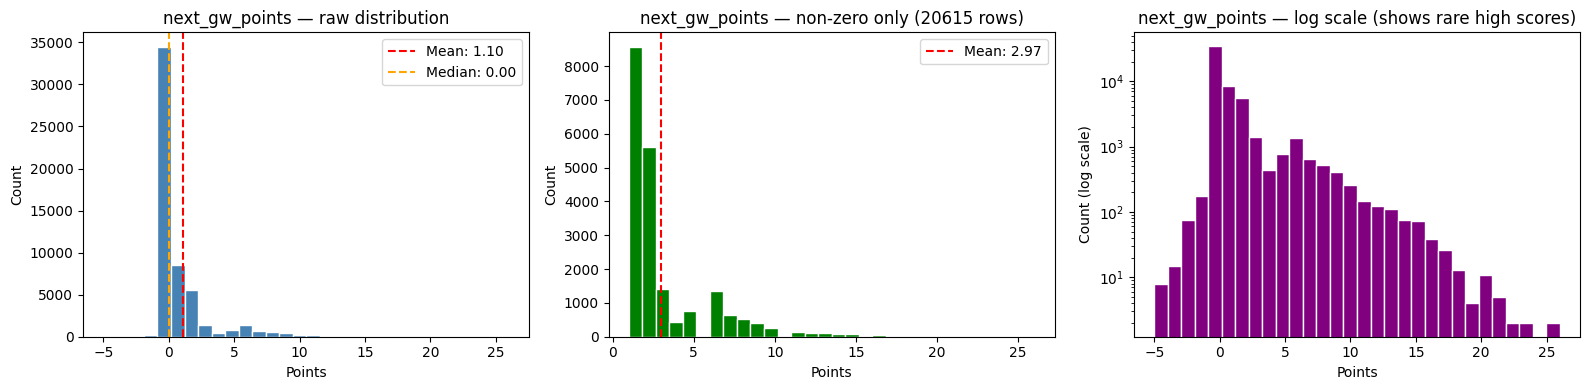

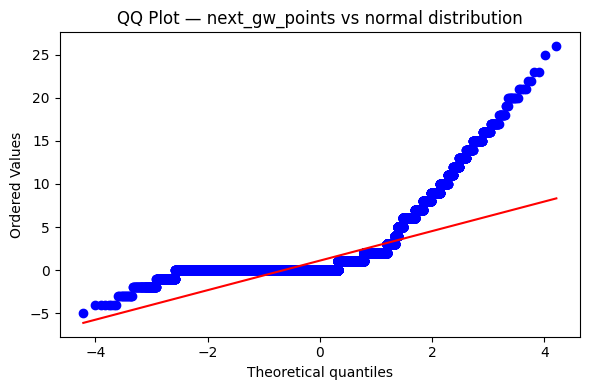


=== SKEWNESS INTERPRETATION ===
Skewness = 3.25 — HIGHLY right skewed
Most values cluster near 0, long tail of high scores
This is expected for FPL — most players blank most weeks
Impact on model: XGBoost handles this well without transformation
Linear Regression will struggle with this distribution


In [10]:
print('=== SKEWNESS ANALYSIS ===')
print(f'Skewness of next_gw_points: {train_df["next_gw_points"].skew():.4f}')
print(f'Kurtosis of next_gw_points: {train_df["next_gw_points"].kurtosis():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1 — Raw distribution
axes[0].hist(train_df['next_gw_points'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('next_gw_points — raw distribution')
axes[0].set_xlabel('Points')
axes[0].set_ylabel('Count')
axes[0].axvline(train_df['next_gw_points'].mean(),   color='red',    linestyle='--', label=f'Mean: {train_df["next_gw_points"].mean():.2f}')
axes[0].axvline(train_df['next_gw_points'].median(), color='orange', linestyle='--', label=f'Median: {train_df["next_gw_points"].median():.2f}')
axes[0].legend()

# Plot 2 — Excluding zeros (to see the scoring distribution clearly)
non_zero = train_df[train_df['next_gw_points'] > 0]['next_gw_points']
axes[1].hist(non_zero, bins=30, color='green', edgecolor='white')
axes[1].set_title(f'next_gw_points — non-zero only ({len(non_zero)} rows)')
axes[1].set_xlabel('Points')
axes[1].set_ylabel('Count')
axes[1].axvline(non_zero.mean(), color='red', linestyle='--', label=f'Mean: {non_zero.mean():.2f}')
axes[1].legend()

# Plot 3 — Log scale to see the tail
axes[2].hist(train_df['next_gw_points'], bins=30, color='purple', edgecolor='white', log=True)
axes[2].set_title('next_gw_points — log scale (shows rare high scores)')
axes[2].set_xlabel('Points')
axes[2].set_ylabel('Count (log scale)')

plt.tight_layout()
plt.show()

# QQ plot to show how far from normal
fig, ax = plt.subplots(figsize=(6, 4))
stats.probplot(train_df['next_gw_points'], dist='norm', plot=ax)
ax.set_title('QQ Plot — next_gw_points vs normal distribution')
plt.tight_layout()
plt.show()

print('\n=== SKEWNESS INTERPRETATION ===')
skew = train_df['next_gw_points'].skew()
if skew > 1:
    print(f'Skewness = {skew:.2f} — HIGHLY right skewed')
    print('Most values cluster near 0, long tail of high scores')
    print('This is expected for FPL — most players blank most weeks')
    print('Impact on model: XGBoost handles this well without transformation')
    print('Linear Regression will struggle with this distribution')

Skewness 3.25  — extremely right skewed
                 anything above 1 is considered high
                 3.25 means a very long tail of rare high scores
                 the bulk of data sits at 0

Kurtosis 13.03 — extremely heavy tailed
                 normal distribution has kurtosis of 3
                 13 means extreme values (20+ point hauls) are
                 far more common than a normal distribution would predict


In [11]:
print('=== FEATURE STATISTICS ===')
feature_cols = [
    'pts_rolling_3gw', 'pts_rolling_5gw',
    'minutes_rolling_3gw',
    'goals_rolling_5gw', 'assists_rolling_5gw',
    'clean_sheets_rolling_5gw',
    'saves_rolling_3gw',
    'bonus_rolling_3gw', 'bps_rolling_3gw',
    'ict_rolling_3gw',
    'xg_rolling_5gw', 'xa_rolling_5gw', 'xgi_rolling_5gw',
    'position_encoded',
    'was_home',
    'price_current',
    'ownership_count',
    'shots_per_90', 'shots_on_target_per_90',
    'xg_per_90', 'xa_per_90',
    'on_off_diff', 'gk_save_pct'
]

stats_df = train_df[feature_cols].describe().T.round(3)
print(stats_df[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])

=== FEATURE STATISTICS ===
                            count        mean         std     min     25%  \
pts_rolling_3gw           53717.0       1.103       1.784  -2.000     0.0   
pts_rolling_5gw           53717.0       1.104       1.648  -2.000     0.0   
minutes_rolling_3gw       53717.0      26.454      34.747   0.000     0.0   
goals_rolling_5gw         53717.0       0.040       0.129   0.000     0.0   
assists_rolling_5gw       53717.0       0.036       0.112   0.000     0.0   
clean_sheets_rolling_5gw  53717.0       0.070       0.150   0.000     0.0   
saves_rolling_3gw         53717.0       0.085       0.540   0.000     0.0   
bonus_rolling_3gw         53717.0       0.085       0.288   0.000     0.0   
bps_rolling_3gw           53717.0       4.740       7.333 -10.333     0.0   
ict_rolling_3gw           53717.0       1.425       2.301   0.000     0.0   
xg_rolling_5gw            53717.0       0.041       0.102   0.000     0.0   
xa_rolling_5gw            53717.0       0.026    

In [12]:
print('=== INVESTIGATING CRITICAL ISSUES ===')

# Issue 1 — xg_per_90 and xa_per_90
print('xg_per_90 unique values:', train_df['xg_per_90'].unique()[:10])
print('xa_per_90 unique values:', train_df['xa_per_90'].unique()[:10])
print('xg_per_90 non-zero count:', (train_df['xg_per_90'] != 0).sum())
print('xa_per_90 non-zero count:', (train_df['xa_per_90'] != 0).sum())

# Issue 2 — ownership_count distribution
print('\nownership_count percentiles:')
print(train_df['ownership_count'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

# Issue 3 — shots per 90 outliers
print('\nshots_per_90 > 10:', (train_df['shots_per_90'] > 10).sum())
print('shots_per_90 > 5:', (train_df['shots_per_90'] > 5).sum())
print('shots_on_target_per_90 > 10:', (train_df['shots_on_target_per_90'] > 10).sum())
print('\nTop 10 shots_per_90 values:')
print(train_df[train_df['shots_per_90'] > 5][['web_name', 'season', 'GW', 'shots_per_90', 'shots_on_target_per_90']].head(10))

# Issue 4 — gk_save_pct
print('\ngk_save_pct > 90:', (train_df['gk_save_pct'] > 90).sum())
print('gk_save_pct non-zero:', (train_df['gk_save_pct'] > 0).sum())
print('\nTop 10 gk_save_pct values:')
print(train_df[train_df['gk_save_pct'] > 0][['web_name', 'position', 'season', 'GW', 'gk_save_pct']].head(10))

=== INVESTIGATING CRITICAL ISSUES ===
xg_per_90 unique values: [0.]
xa_per_90 unique values: [0.]
xg_per_90 non-zero count: 0
xa_per_90 non-zero count: 0

ownership_count percentiles:
0.25       3531.50
0.50      16904.00
0.75     113746.00
0.90     544216.00
0.95    1113700.80
0.99    3303325.86
Name: ownership_count, dtype: float64

shots_per_90 > 10: 115
shots_per_90 > 5: 316
shots_on_target_per_90 > 10: 43

Top 10 shots_per_90 values:
           web_name   season  GW  shots_per_90  shots_on_target_per_90
148  Mohamed Elneny  2023/24   1          6.43                    3.21
149  Mohamed Elneny  2023/24   2          6.43                    3.21
150  Mohamed Elneny  2023/24   3          6.43                    3.21
151  Mohamed Elneny  2023/24   4          6.43                    3.21
152  Mohamed Elneny  2023/24   5          6.43                    3.21
153  Mohamed Elneny  2023/24   6          6.43                    3.21
154  Mohamed Elneny  2023/24   7          6.43              

In [13]:
print('=== CAP VALUES FOR FIXING ===')

# shots_per_90 cap
p99_shots = train_df['shots_per_90'].quantile(0.99)
p99_sot   = train_df['shots_on_target_per_90'].quantile(0.99)
p99_gk    = train_df['gk_save_pct'].quantile(0.99)

print(f'shots_per_90        99th percentile: {p99_shots:.3f}')
print(f'shots_on_target_90  99th percentile: {p99_sot:.3f}')
print(f'gk_save_pct         99th percentile: {p99_gk:.3f}')

# ownership log transform preview
import numpy as np
train_df['ownership_log'] = np.log1p(train_df['ownership_count'])
print(f'\nownership_count    min={train_df["ownership_count"].min():.0f}  max={train_df["ownership_count"].max():.0f}')
print(f'ownership_log      min={train_df["ownership_log"].min():.3f}  max={train_df["ownership_log"].max():.3f}')
print(f'\nownership_log percentiles:')
print(train_df['ownership_log'].quantile([0.25, 0.5, 0.75, 0.9, 0.99]).round(3))

# Confirm xg_per_90 and xa_per_90 are fully zero
print(f'\nxg_per_90 sum: {train_df["xg_per_90"].sum()}')
print(f'xa_per_90 sum: {train_df["xa_per_90"].sum()}')
print('Both confirmed empty — will be dropped')


=== CAP VALUES FOR FIXING ===
shots_per_90        99th percentile: 4.440
shots_on_target_90  99th percentile: 1.800
gk_save_pct         99th percentile: 72.900

ownership_count    min=0  max=9241818
ownership_log      min=0.000  max=16.039

ownership_log percentiles:
0.25     8.170
0.50     9.735
0.75    11.642
0.90    13.207
0.99    15.010
Name: ownership_log, dtype: float64

xg_per_90 sum: 0.0
xa_per_90 sum: 0.0
Both confirmed empty — will be dropped


=== FEATURE CORRELATIONS WITH next_gw_points ===
pts_rolling_5gw             0.4683
minutes_rolling_3gw         0.4678
ict_rolling_3gw             0.4651
pts_rolling_3gw             0.4470
bps_rolling_3gw             0.4455
xgi_rolling_5gw             0.4031
xa_rolling_5gw              0.3550
xg_rolling_5gw              0.3457
clean_sheets_rolling_5gw    0.3351
price_current               0.3194
ownership_count             0.3188
goals_rolling_5gw           0.2993
bonus_rolling_3gw           0.2808
assists_rolling_5gw         0.2672
shots_per_90                0.1207
saves_rolling_3gw           0.1045
on_off_diff                 0.0674
shots_on_target_per_90      0.0645
position_encoded            0.0625
gk_save_pct                 0.0417
was_home                   -0.0098


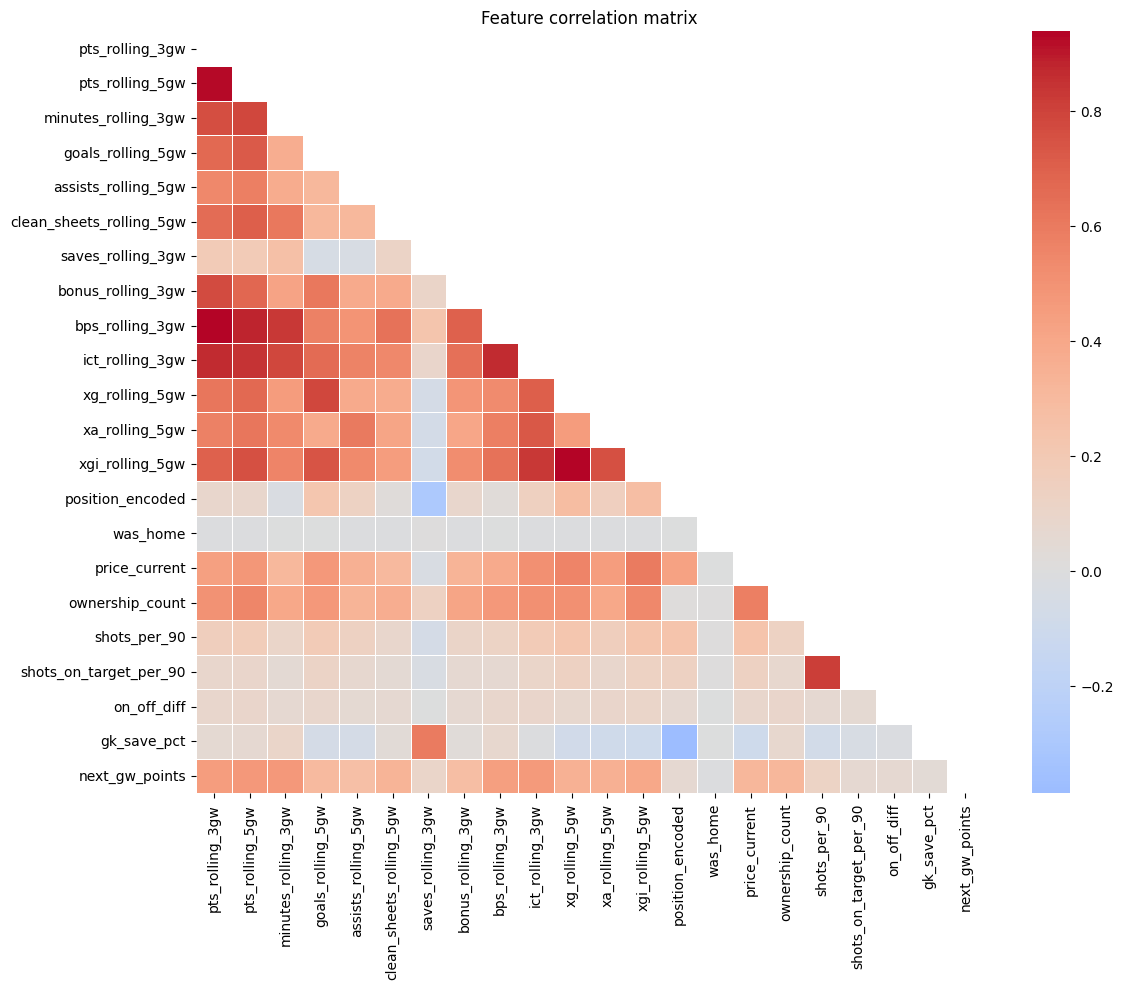

In [14]:
# Updated feature list without the two dropped columns
feature_cols_updated = [
    'pts_rolling_3gw', 'pts_rolling_5gw',
    'minutes_rolling_3gw',
    'goals_rolling_5gw', 'assists_rolling_5gw',
    'clean_sheets_rolling_5gw',
    'saves_rolling_3gw',
    'bonus_rolling_3gw', 'bps_rolling_3gw',
    'ict_rolling_3gw',
    'xg_rolling_5gw', 'xa_rolling_5gw', 'xgi_rolling_5gw',
    'position_encoded',
    'was_home',
    'price_current',
    'ownership_count',
    'shots_per_90', 'shots_on_target_per_90',
    'on_off_diff',
    'gk_save_pct'
]

print('=== FEATURE CORRELATIONS WITH next_gw_points ===')
corr = train_df[feature_cols_updated + ['next_gw_points']].corr()['next_gw_points'].drop('next_gw_points')
corr_sorted = corr.sort_values(ascending=False)
print(corr_sorted.round(4).to_string())

# Heatmap
plt.figure(figsize=(12, 10))
corr_matrix = train_df[feature_cols_updated + ['next_gw_points']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.show()

In [15]:
print('Validation shape:', val_df.shape)
print('\nColumns:')
print(list(val_df.columns))


Validation shape: (28906, 29)

Columns:
['element', 'web_name', 'position', 'season', 'GW', 'pts_rolling_3gw', 'pts_rolling_5gw', 'minutes_rolling_3gw', 'goals_rolling_5gw', 'assists_rolling_5gw', 'clean_sheets_rolling_5gw', 'saves_rolling_3gw', 'bonus_rolling_3gw', 'bps_rolling_3gw', 'ict_rolling_3gw', 'xg_rolling_5gw', 'xa_rolling_5gw', 'xgi_rolling_5gw', 'position_encoded', 'was_home', 'price_current', 'ownership_count', 'shots_per_90', 'shots_on_target_per_90', 'xg_per_90', 'xa_per_90', 'on_off_diff', 'gk_save_pct', 'next_gw_points']


In [16]:
print(val_df.dtypes)

element                       int64
web_name                     object
position                     object
season                       object
GW                            int64
pts_rolling_3gw             float64
pts_rolling_5gw             float64
minutes_rolling_3gw         float64
goals_rolling_5gw           float64
assists_rolling_5gw         float64
clean_sheets_rolling_5gw    float64
saves_rolling_3gw           float64
bonus_rolling_3gw           float64
bps_rolling_3gw             float64
ict_rolling_3gw             float64
xg_rolling_5gw              float64
xa_rolling_5gw              float64
xgi_rolling_5gw             float64
position_encoded              int64
was_home                      int64
price_current               float64
ownership_count               int64
shots_per_90                float64
shots_on_target_per_90      float64
xg_per_90                   float64
xa_per_90                   float64
on_off_diff                 float64
gk_save_pct                 

In [17]:
nulls = val_df.isnull().sum()
pct   = (nulls / len(val_df) * 100).round(2)
null_df = pd.DataFrame({'count': nulls, 'pct%': pct})
print(null_df)

                          count  pct%
element                       0  0.00
web_name                      0  0.00
position                      0  0.00
season                        0  0.00
GW                            0  0.00
pts_rolling_3gw             840  2.91
pts_rolling_5gw             840  2.91
minutes_rolling_3gw         840  2.91
goals_rolling_5gw           840  2.91
assists_rolling_5gw         840  2.91
clean_sheets_rolling_5gw    840  2.91
saves_rolling_3gw           840  2.91
bonus_rolling_3gw           840  2.91
bps_rolling_3gw             840  2.91
ict_rolling_3gw             840  2.91
xg_rolling_5gw              840  2.91
xa_rolling_5gw              840  2.91
xgi_rolling_5gw             840  2.91
position_encoded              0  0.00
was_home                      0  0.00
price_current                 0  0.00
ownership_count               0  0.00
shots_per_90                  0  0.00
shots_on_target_per_90        0  0.00
xg_per_90                     0  0.00
xa_per_90   

In [18]:
null_rows = val_df[val_df['pts_rolling_3gw'].isnull()]
print(f'Total null rows: {len(null_rows)}')
print('\nBy GW:')
print(null_rows['GW'].value_counts().sort_index())

Total null rows: 840

By GW:
GW
1     690
2      15
3       7
4      28
5       1
6       1
7       1
8       2
9       1
10      1
11      5
12      3
14      3
15      1
16      1
17     10
18      5
19      5
20     10
21      5
22      4
23      4
24      8
25      6
27      1
28      1
29      1
30      2
31      3
32      1
33      3
34      1
35      2
36      6
37      2
Name: count, dtype: int64


# **Data Cleaning**

In [19]:
#Duplicates
# Exact duplicates
exact_dupes = train_df.duplicated().sum()
print(f'Exact duplicate rows: {exact_dupes}')

# Player-GW duplicates (same player, same gameweek, same season)
player_gw_dupes = train_df.duplicated(
    subset=['element', 'GW', 'season'], keep=False
)
print(f'Player-GW duplicate rows: {player_gw_dupes.sum()}')

if player_gw_dupes.sum() > 0:
    print('\nSample duplicates:')
    print(
        train_df[player_gw_dupes][
            ['element', 'web_name', 'season', 'GW', 'next_gw_points']
        ]
        .sort_values(['element', 'season', 'GW'])
        .head(20)
        .to_string()
    )

Exact duplicate rows: 342
Player-GW duplicate rows: 2694

Sample duplicates:
     element                      web_name   season  GW  next_gw_points
32         1               Folarin Balogun  2023/24  34             0.0
33         1               Folarin Balogun  2023/24  34             0.0
69         1         Fábio Ferreira Vieira  2024/25  33             0.0
70         1         Fábio Ferreira Vieira  2024/25  33             0.0
106        2           Cédric Alves Soares  2023/24  34             0.0
107        2           Cédric Alves Soares  2023/24  34             0.0
143        2     Gabriel Fernando de Jesus  2024/25  33             0.0
144        2     Gabriel Fernando de Jesus  2024/25  33             0.0
180        3                Mohamed Elneny  2023/24  34             0.0
181        3                Mohamed Elneny  2023/24  34             0.0
217        3  Gabriel dos Santos Magalhães  2024/25  33             0.0
218        3  Gabriel dos Santos Magalhães  2024/25  33    

In [20]:
# Which GWs have the most duplicates
print('Player-GW duplicates by GW:')
dupes_mask = train_df.duplicated(subset=['element', 'GW', 'season'], keep=False)
dupes_df   = train_df[dupes_mask]
print(dupes_df.groupby(['season', 'GW']).size().sort_values(ascending=False).head(20))

# How many have different next_gw_points values
print('\nDuplicates with conflicting next_gw_points:')
conflict = (
    train_df.groupby(['element', 'GW', 'season'])['next_gw_points']
    .nunique()
    .reset_index()
)
conflict.columns = ['element', 'GW', 'season', 'unique_target_values']
conflicting = conflict[conflict['unique_target_values'] > 1]
print(f'Player-GW pairs with conflicting target values: {len(conflicting)}')
print(conflicting.head(20).to_string())

# How many have different feature values
print('\nDuplicates with conflicting pts_rolling_3gw:')
conflict_feat = (
    train_df.groupby(['element', 'GW', 'season'])['pts_rolling_3gw']
    .nunique()
    .reset_index()
)
conflict_feat.columns = ['element', 'GW', 'season', 'unique_feat_values']
conflicting_feat = conflict_feat[conflict_feat['unique_feat_values'] > 1]
print(f'Player-GW pairs with conflicting feature values: {len(conflicting_feat)}')

Player-GW duplicates by GW:
season   GW
2023/24  34    568
         37    542
         25    318
2024/25  33    302
2023/24  35    202
         28    172
         7     164
2024/25  25    154
         32    138
         24    134
dtype: int64

Duplicates with conflicting next_gw_points:
Player-GW pairs with conflicting target values: 453
      element  GW   season  unique_target_values
281         4  34  2023/24                     2
353         5  34  2023/24                     2
424         6  33  2024/25                     2
425         6  34  2023/24                     2
568         8  33  2024/25                     2
569         8  34  2023/24                     2
641         9  34  2023/24                     2
713        10  34  2023/24                     2
784        11  33  2024/25                     2
928        13  33  2024/25                     2
1001       14  34  2023/24                     2
1074       15  34  2023/24                     2
1145       16  33  2024

In [21]:
print(f'Rows before cleaning: {len(train_df)}')

# Step 1 — Remove exact duplicates
train_df = train_df.drop_duplicates()
print(f'After removing exact duplicates: {len(train_df)}')

# Step 2 — For player-GW conflicts keep row with highest next_gw_points
# (bonus revisions add points, so higher value is more likely correct)
# Sort so highest next_gw_points comes first within each group
train_df = train_df.sort_values(
    ['element', 'season', 'GW', 'next_gw_points'],
    ascending=[True, True, True, False]
)

# Keep first occurrence (highest next_gw_points) per player-GW-season
before = len(train_df)
train_df = train_df.drop_duplicates(
    subset=['element', 'GW', 'season'],
    keep='first'
)
print(f'After removing player-GW conflicts: {len(train_df)}')
print(f'Total rows removed: {before - len(train_df)}')

# Step 3 — Reset index
train_df = train_df.reset_index(drop=True)
print(f'Final training shape: {train_df.shape}')

# Step 4 — Verify no duplicates remain
remaining_exact = train_df.duplicated().sum()
remaining_gw    = train_df.duplicated(subset=['element', 'GW', 'season']).sum()
print(f'\nRemaining exact duplicates: {remaining_exact}')
print(f'Remaining player-GW duplicates: {remaining_gw}')

if remaining_exact == 0 and remaining_gw == 0:
    print('Duplicate check PASSED')
else:
    print('WARNING — duplicates still present, investigate')

Rows before cleaning: 55359
After removing exact duplicates: 55017
After removing player-GW conflicts: 54012
Total rows removed: 1005
Final training shape: (54012, 30)

Remaining exact duplicates: 0
Remaining player-GW duplicates: 0
Duplicate check PASSED


In [22]:
print('=== RANGE VALIDATION AND FIXING ===')

# Check before fixing
print('BEFORE FIXES:')
print(f'next_gw_points outside [-5, 30]: {((train_df["next_gw_points"] < -5) | (train_df["next_gw_points"] > 30)).sum()}')
print(f'price_current outside [3.5, 16.0]: {((train_df["price_current"] < 3.5) | (train_df["price_current"] > 16.0)).sum()}')
print(f'was_home values: {train_df["was_home"].value_counts().to_dict()}')
print(f'position_encoded values: {sorted(train_df["position_encoded"].unique())}')

# Fix position_encoded dtype
train_df['position_encoded'] = train_df['position_encoded'].astype(int)
print(f'\nposition_encoded dtype after fix: {train_df["position_encoded"].dtype}')
print(f'position_encoded values: {sorted(train_df["position_encoded"].unique())}')

# Confirm was_home is binary
invalid_home = (~train_df['was_home'].isin([0, 1])).sum()
print(f'Invalid was_home values: {invalid_home}')

# Confirm next_gw_points range
print(f'\nnext_gw_points min: {train_df["next_gw_points"].min()}')
print(f'next_gw_points max: {train_df["next_gw_points"].max()}')

print('\nRange validation PASSED' if (
    train_df['next_gw_points'].min() >= -5 and
    train_df['next_gw_points'].max() <= 30 and
    invalid_home == 0
) else 'WARNING — range issues found')

=== RANGE VALIDATION AND FIXING ===
BEFORE FIXES:
next_gw_points outside [-5, 30]: 0
price_current outside [3.5, 16.0]: 0
was_home values: {0: 27046, 1: 26966}
position_encoded values: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]

position_encoded dtype after fix: int64
position_encoded values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Invalid was_home values: 0

next_gw_points min: -5.0
next_gw_points max: 26.0

Range validation PASSED


In [23]:
print('Current columns:')
print(list(train_df.columns))
print(f'\nTotal columns: {len(train_df.columns)}')

Current columns:
['element', 'web_name', 'position', 'season', 'GW', 'pts_rolling_3gw', 'pts_rolling_5gw', 'minutes_rolling_3gw', 'goals_rolling_5gw', 'assists_rolling_5gw', 'clean_sheets_rolling_5gw', 'saves_rolling_3gw', 'bonus_rolling_3gw', 'bps_rolling_3gw', 'ict_rolling_3gw', 'xg_rolling_5gw', 'xa_rolling_5gw', 'xgi_rolling_5gw', 'position_encoded', 'was_home', 'price_current', 'ownership_count', 'shots_per_90', 'shots_on_target_per_90', 'xg_per_90', 'xa_per_90', 'on_off_diff', 'gk_save_pct', 'next_gw_points', 'ownership_log']

Total columns: 30


In [24]:
print('=== TRAINING vs VALIDATION COMPARISON ===')

print('\nTarget — next_gw_points:')
comparison = pd.DataFrame({
    'training':   train_df['next_gw_points'].describe(),
    'validation': val_df['next_gw_points'].describe()
}).round(4)
print(comparison)

print('\nBlank rate (0 points):')
train_blank = (train_df['next_gw_points'] == 0).sum() / len(train_df) * 100
val_blank   = (val_df['next_gw_points'] == 0).sum() / len(val_df) * 100
print(f'Training:   {train_blank:.1f}%')
print(f'Validation: {val_blank:.1f}%')

print('\nPosition distribution:')
train_pos = train_df['position'].value_counts(normalize=True).round(3)
val_pos   = val_df['position'].value_counts(normalize=True).round(3)
pos_df    = pd.DataFrame({'training': train_pos, 'validation': val_pos})
print(pos_df)

print('\nGW range:')
print(f'Training:   GW{train_df["GW"].min()} to GW{train_df["GW"].max()}')
print(f'Validation: GW{val_df["GW"].min()} to GW{val_df["GW"].max()}')

print('\nUnique players:')
print(f'Training:   {train_df["element"].nunique()}')
print(f'Validation: {val_df["element"].nunique()}')

print('\nNew players in validation not seen in training:')
train_ids = set(train_df['element'].unique())
val_ids   = set(val_df['element'].unique())
new_players = val_ids - train_ids
print(f'Count: {len(new_players)}')
if len(new_players) > 0:
    sample = val_df[val_df['element'].isin(list(new_players)[:10])][['element', 'web_name', 'position']].drop_duplicates()
    print(sample.to_string())

=== TRAINING vs VALIDATION COMPARISON ===

Target — next_gw_points:
         training  validation
count  54012.0000  28906.0000
mean       1.1126      1.1533
std        2.3263      2.3506
min       -5.0000     -3.0000
25%        0.0000      0.0000
50%        0.0000      0.0000
75%        1.0000      1.0000
max       26.0000     24.0000

Blank rate (0 points):
Training:   62.0%
Validation: 63.1%

Position distribution:
          training  validation
position                      
DEF          0.329       0.327
FWD          0.121       0.110
GK           0.110       0.115
MID          0.440       0.447

GW range:
Training:   GW1 to GW37
Validation: GW1 to GW37

Unique players:
Training:   862
Validation: 840

New players in validation not seen in training:
Count: 0


In [25]:
print('\nGW range:')
print(f'Training:   GW{train_df["GW"].min()} to GW{train_df["GW"].max()}')
print(f'Validation: GW{val_df["GW"].min()} to GW{val_df["GW"].max()}')

print('\nUnique players:')
print(f'Training:   {train_df["element"].nunique()}')
print(f'Validation: {val_df["element"].nunique()}')

print('\nNew players in validation not seen in training:')
train_ids   = set(train_df['element'].unique())
val_ids     = set(val_df['element'].unique())
new_players = val_ids - train_ids
print(f'Count: {len(new_players)}')
if len(new_players) > 0:
    sample = val_df[
        val_df['element'].isin(list(new_players)[:10])
    ][['element', 'web_name', 'position']].drop_duplicates()
    print(sample.to_string())


GW range:
Training:   GW1 to GW37
Validation: GW1 to GW37

Unique players:
Training:   862
Validation: 840

New players in validation not seen in training:
Count: 0


In [26]:
print('=== APPLYING ALL CLEANING TO BOTH DATAFRAMES ===')

# TRAINING: Remove duplicates
print('\n-- Training duplicates --')
before = len(train_df)
train_df = train_df.drop_duplicates()
train_df = train_df.sort_values(
    ['element', 'season', 'GW', 'next_gw_points'],
    ascending=[True, True, True, False]
)
train_df = train_df.drop_duplicates(
    subset=['element', 'GW', 'season'],
    keep='first'
).reset_index(drop=True)
print(f'Rows before: {before} after: {len(train_df)} removed: {before - len(train_df)}')

# BOTH: Fix position_encoded dtype
train_df['position_encoded'] = train_df['position_encoded'].astype(int)
val_df['position_encoded']   = val_df['position_encoded'].astype(int)
print(f'\nposition_encoded dtype fixed')

# BOTH: Drop zero variance columns
cols_to_drop = [c for c in ['xg_per_90', 'xa_per_90'] if c in train_df.columns]
if cols_to_drop:
    train_df = train_df.drop(columns=cols_to_drop)
    val_df   = val_df.drop(columns=cols_to_drop)
    print(f'Dropped: {cols_to_drop}')
else:
    print('xg_per_90 and xa_per_90 already removed')

# BOTH: Log transform ownership
if 'ownership_log' not in train_df.columns:
    train_df['ownership_log'] = np.log1p(train_df['ownership_count'])
    val_df['ownership_log']   = np.log1p(val_df['ownership_count'])
    print('ownership_log created')
else:
    print('ownership_log already exists — skipping')

# BOTH: Cap outliers
train_df['shots_per_90']           = train_df['shots_per_90'].clip(upper=4.440)
train_df['shots_on_target_per_90'] = train_df['shots_on_target_per_90'].clip(upper=1.800)
train_df['gk_save_pct']            = train_df['gk_save_pct'].clip(upper=72.900)
val_df['shots_per_90']             = val_df['shots_per_90'].clip(upper=4.440)
val_df['shots_on_target_per_90']   = val_df['shots_on_target_per_90'].clip(upper=1.800)
val_df['gk_save_pct']              = val_df['gk_save_pct'].clip(upper=72.900)

print(f'Outliers capped')

# FINAL STATE
print('\n=== FINAL STATE ===')
print(f'Training shape:   {train_df.shape}')
print(f'Validation shape: {val_df.shape}')
print(f'Training duplicates: {train_df.duplicated(subset=["element","GW","season"]).sum()}')
print(f'Validation duplicates: {val_df.duplicated(subset=["element","GW","season"]).sum()}')
print(f'\nNull counts training:')
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])
print(f'\nNull counts validation:')
print(val_df.isnull().sum()[val_df.isnull().sum() > 0])

=== APPLYING ALL CLEANING TO BOTH DATAFRAMES ===

-- Training duplicates --
Rows before: 54012 after: 54012 removed: 0

position_encoded dtype fixed
Dropped: ['xg_per_90', 'xa_per_90']
ownership_log already exists — skipping
Outliers capped

=== FINAL STATE ===
Training shape:   (54012, 28)
Validation shape: (28906, 27)
Training duplicates: 0
Validation duplicates: 409

Null counts training:
pts_rolling_3gw             1641
pts_rolling_5gw             1641
minutes_rolling_3gw         1641
goals_rolling_5gw           1641
assists_rolling_5gw         1641
clean_sheets_rolling_5gw    1641
saves_rolling_3gw           1641
bonus_rolling_3gw           1641
bps_rolling_3gw             1641
ict_rolling_3gw             1641
xg_rolling_5gw              1641
xa_rolling_5gw              1641
xgi_rolling_5gw             1641
dtype: int64

Null counts validation:
pts_rolling_3gw             840
pts_rolling_5gw             840
minutes_rolling_3gw         840
goals_rolling_5gw           840
assists_ro

In [27]:
print('=== FIXING VALIDATION DUPLICATES ===')
print(f'Validation rows before: {len(val_df)}')

# Check what GWs the duplicates are in
dupes_mask = val_df.duplicated(subset=['element', 'GW', 'season'], keep=False)
print(f'\nDuplicate rows by GW:')
print(val_df[dupes_mask].groupby('GW').size().sort_values(ascending=False).head(10))

# Remove exact duplicates first
val_df = val_df.drop_duplicates()
print(f'\nAfter exact duplicate removal: {len(val_df)}')

# Remove player-GW conflicts keeping highest next_gw_points
val_df = val_df.sort_values(
    ['element', 'season', 'GW', 'next_gw_points'],
    ascending=[True, True, True, False]
)
val_df = val_df.drop_duplicates(
    subset=['element', 'GW', 'season'],
    keep='first'
).reset_index(drop=True)

print(f'After player-GW dedup: {len(val_df)}')
print(f'Validation duplicates remaining: {val_df.duplicated(subset=["element","GW","season"]).sum()}')
print(f'Final validation shape: {val_df.shape}')

=== FIXING VALIDATION DUPLICATES ===
Validation rows before: 28906

Duplicate rows by GW:
GW
33    496
36    164
26    158
dtype: int64

After exact duplicate removal: 28872
After player-GW dedup: 28497
Validation duplicates remaining: 0
Final validation shape: (28497, 27)


In [28]:
print('val_df columns:')
print(list(val_df.columns))
print('\ntrain_df columns:')
print(list(train_df.columns))

val_df columns:
['element', 'web_name', 'position', 'season', 'GW', 'pts_rolling_3gw', 'pts_rolling_5gw', 'minutes_rolling_3gw', 'goals_rolling_5gw', 'assists_rolling_5gw', 'clean_sheets_rolling_5gw', 'saves_rolling_3gw', 'bonus_rolling_3gw', 'bps_rolling_3gw', 'ict_rolling_3gw', 'xg_rolling_5gw', 'xa_rolling_5gw', 'xgi_rolling_5gw', 'position_encoded', 'was_home', 'price_current', 'ownership_count', 'shots_per_90', 'shots_on_target_per_90', 'on_off_diff', 'gk_save_pct', 'next_gw_points']

train_df columns:
['element', 'web_name', 'position', 'season', 'GW', 'pts_rolling_3gw', 'pts_rolling_5gw', 'minutes_rolling_3gw', 'goals_rolling_5gw', 'assists_rolling_5gw', 'clean_sheets_rolling_5gw', 'saves_rolling_3gw', 'bonus_rolling_3gw', 'bps_rolling_3gw', 'ict_rolling_3gw', 'xg_rolling_5gw', 'xa_rolling_5gw', 'xgi_rolling_5gw', 'position_encoded', 'was_home', 'price_current', 'ownership_count', 'shots_per_90', 'shots_on_target_per_90', 'on_off_diff', 'gk_save_pct', 'next_gw_points', 'ownershi

In [29]:
# Fix val_df to match train_df
val_df['ownership_log'] = np.log1p(val_df['ownership_count'])

# Confirm both now have same columns
print('ownership_log in train_df:', 'ownership_log' in train_df.columns)
print('ownership_log in val_df:',   'ownership_log' in val_df.columns)
print('\nval_df columns:', list(val_df.columns))

ownership_log in train_df: True
ownership_log in val_df: True

val_df columns: ['element', 'web_name', 'position', 'season', 'GW', 'pts_rolling_3gw', 'pts_rolling_5gw', 'minutes_rolling_3gw', 'goals_rolling_5gw', 'assists_rolling_5gw', 'clean_sheets_rolling_5gw', 'saves_rolling_3gw', 'bonus_rolling_3gw', 'bps_rolling_3gw', 'ict_rolling_3gw', 'xg_rolling_5gw', 'xa_rolling_5gw', 'xgi_rolling_5gw', 'position_encoded', 'was_home', 'price_current', 'ownership_count', 'shots_per_90', 'shots_on_target_per_90', 'on_off_diff', 'gk_save_pct', 'next_gw_points', 'ownership_log']


In [30]:
feature_cols = [
    'pts_rolling_3gw', 'pts_rolling_5gw',
    'minutes_rolling_3gw',
    'goals_rolling_5gw', 'assists_rolling_5gw',
    'clean_sheets_rolling_5gw',
    'saves_rolling_3gw',
    'bonus_rolling_3gw', 'bps_rolling_3gw',
    'ict_rolling_3gw',
    'xg_rolling_5gw', 'xa_rolling_5gw', 'xgi_rolling_5gw',
    'position_encoded',
    'was_home',
    'price_current',
    'ownership_log',
    'shots_per_90', 'shots_on_target_per_90',
    'on_off_diff',
    'gk_save_pct'
]
target_col = 'next_gw_points'

# Split
X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()
X_val   = val_df[feature_cols].copy()
y_val   = val_df[target_col].copy()

print(f'X_train: {X_train.shape}')
print(f'X_val:   {X_val.shape}')

# Baseline
from sklearn.metrics import mean_squared_error, mean_absolute_error

mean_prediction = y_train.mean()
baseline_preds  = np.full(len(y_val), mean_prediction)
baseline_rmse   = np.sqrt(mean_squared_error(y_val, baseline_preds))
baseline_mae    = mean_absolute_error(y_val, baseline_preds)

print(f'\n=== BASELINE ===')
print(f'Mean prediction: {mean_prediction:.4f}')
print(f'Baseline RMSE:   {baseline_rmse:.4f}')
print(f'Baseline MAE:    {baseline_mae:.4f}')
print(f'\nBoth models must beat RMSE of {baseline_rmse:.4f}')

X_train: (54012, 21)
X_val:   (28497, 21)

=== BASELINE ===
Mean prediction: 1.1126
Baseline RMSE:   2.3629
Baseline MAE:    1.4968

Both models must beat RMSE of 2.3629


In [31]:
print('=== FIXING VALIDATION DUPLICATES ===')
print(f'Validation rows before: {len(val_df)}')

# Check what GWs the duplicates are in
dupes_mask = val_df.duplicated(subset=['element', 'GW', 'season'], keep=False)
print(f'\nDuplicate rows by GW:')
print(val_df[dupes_mask].groupby('GW').size().sort_values(ascending=False).head(10))

# Remove exact duplicates first
val_df = val_df.drop_duplicates()
print(f'\nAfter exact duplicate removal: {len(val_df)}')

# Remove player-GW conflicts keeping highest next_gw_points
val_df = val_df.sort_values(
    ['element', 'season', 'GW', 'next_gw_points'],
    ascending=[True, True, True, False]
)
val_df = val_df.drop_duplicates(
    subset=['element', 'GW', 'season'],
    keep='first'
).reset_index(drop=True)

print(f'After player-GW dedup: {len(val_df)}')
print(f'Validation duplicates remaining: {val_df.duplicated(subset=["element","GW","season"]).sum()}')
print(f'Final validation shape: {val_df.shape}')

=== FIXING VALIDATION DUPLICATES ===
Validation rows before: 28497

Duplicate rows by GW:
Series([], dtype: int64)

After exact duplicate removal: 28497
After player-GW dedup: 28497
Validation duplicates remaining: 0
Final validation shape: (28497, 28)


## **Feature Engineering**

In [32]:
print('=== FEATURE ENGINEERING ===')

# Final feature list — 21 features
# ownership_count dropped (replaced by ownership_log)
feature_cols = [
    'pts_rolling_3gw',
    'pts_rolling_5gw',
    'minutes_rolling_3gw',
    'goals_rolling_5gw',
    'assists_rolling_5gw',
    'clean_sheets_rolling_5gw',
    'saves_rolling_3gw',
    'bonus_rolling_3gw',
    'bps_rolling_3gw',
    'ict_rolling_3gw',
    'xg_rolling_5gw',
    'xa_rolling_5gw',
    'xgi_rolling_5gw',
    'position_encoded',
    'was_home',
    'price_current',
    'ownership_log',
    'shots_per_90',
    'shots_on_target_per_90',
    'on_off_diff',
    'gk_save_pct'
]

target_col = 'next_gw_points'

# Confirm all feature columns exist
missing = [c for c in feature_cols if c not in train_df.columns]
if missing:
    print(f'MISSING COLUMNS: {missing}')
else:
    print(f'All {len(feature_cols)} feature columns confirmed present')

# Split into X and y
X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_val   = val_df[feature_cols].copy()
y_val   = val_df[target_col].copy()

print(f'\nX_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'y_val:   {y_val.shape}')

print(f'\ny_train — min: {y_train.min()} max: {y_train.max()} mean: {y_train.mean():.4f}')
print(f'y_val   — min: {y_val.min()} max: {y_val.max()} mean: {y_val.mean():.4f}')

print(f'\nTarget nulls — training: {y_train.isnull().sum()}')
print(f'Target nulls — validation: {y_val.isnull().sum()}')

print(f'\nFeature nulls — training:')
feat_nulls = X_train.isnull().sum()
print(feat_nulls[feat_nulls > 0])

print(f'\nFeature nulls — validation:')
feat_nulls_v = X_val.isnull().sum()
print(feat_nulls_v[feat_nulls_v > 0])

=== FEATURE ENGINEERING ===
All 21 feature columns confirmed present

X_train: (54012, 21)
y_train: (54012,)
X_val:   (28497, 21)
y_val:   (28497,)

y_train — min: -5.0 max: 26.0 mean: 1.1126
y_val   — min: -3.0 max: 24.0 mean: 1.1622

Target nulls — training: 0
Target nulls — validation: 0

Feature nulls — training:
pts_rolling_3gw             1641
pts_rolling_5gw             1641
minutes_rolling_3gw         1641
goals_rolling_5gw           1641
assists_rolling_5gw         1641
clean_sheets_rolling_5gw    1641
saves_rolling_3gw           1641
bonus_rolling_3gw           1641
bps_rolling_3gw             1641
ict_rolling_3gw             1641
xg_rolling_5gw              1641
xa_rolling_5gw              1641
xgi_rolling_5gw             1641
dtype: int64

Feature nulls — validation:
pts_rolling_3gw             839
pts_rolling_5gw             839
minutes_rolling_3gw         839
goals_rolling_5gw           839
assists_rolling_5gw         839
clean_sheets_rolling_5gw    839
saves_rolling_3gw 

## **Data Transformation**

In [33]:
print('=== TRANSFORMATION PHASE ===')

# XGBoost — no transformation needed
# Handles nulls natively, handles skewed targets natively
# No scaling needed for tree-based models
print('XGBoost transformation:')
print('  Nulls    — handled natively, no filling')
print('  Scaling  — not needed for trees')
print('  Target   — no transformation, use raw next_gw_points')
print('  X_train and X_val passed directly as is')

# Linear Regression — needs imputation and scaling
# Nulls must be filled (sklearn does not handle NaN)
# Scaling helps LR converge and makes coefficients comparable
print('\nLinear Regression transformation:')
print('  Nulls    — SimpleImputer with mean strategy')
print('  Scaling  — StandardScaler for comparable coefficients')
print('  Target   — no transformation (keep raw for direct comparison with XGBoost)')

# Build Linear Regression preprocessor as a pipeline
# This ensures imputer and scaler are fit ONLY on training data
# then applied to validation — prevents data leakage
lr_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler())
])

# Fit on training only
X_train_lr = lr_preprocessor.fit_transform(X_train)
X_val_lr   = lr_preprocessor.transform(X_val)

print(f'\nX_train_lr shape: {X_train_lr.shape}')
print(f'X_val_lr shape:   {X_val_lr.shape}')
print(f'Any nulls in X_train_lr: {np.isnan(X_train_lr).sum()}')
print(f'Any nulls in X_val_lr:   {np.isnan(X_val_lr).sum()}')

# Confirm scaling worked
print(f'\nX_train_lr mean (should be ~0): {X_train_lr.mean():.6f}')
print(f'X_train_lr std  (should be ~1): {X_train_lr.std():.6f}')

# XGBoost uses X_train and X_val directly (with nulls intact)
print('\nXGBoost will use:')
print(f'  X_train: {X_train.shape} with {X_train.isnull().sum().sum()} nulls (handled natively)')
print(f'  X_val:   {X_val.shape} with {X_val.isnull().sum().sum()} nulls (handled natively)')

print('\nTransformation complete — ready to train')

=== TRANSFORMATION PHASE ===
XGBoost transformation:
  Nulls    — handled natively, no filling
  Scaling  — not needed for trees
  Target   — no transformation, use raw next_gw_points
  X_train and X_val passed directly as is

Linear Regression transformation:
  Nulls    — SimpleImputer with mean strategy
  Scaling  — StandardScaler for comparable coefficients
  Target   — no transformation (keep raw for direct comparison with XGBoost)

X_train_lr shape: (54012, 21)
X_val_lr shape:   (28497, 21)
Any nulls in X_train_lr: 0
Any nulls in X_val_lr:   0

X_train_lr mean (should be ~0): -0.000000
X_train_lr std  (should be ~1): 1.000000

XGBoost will use:
  X_train: (54012, 21) with 21333 nulls (handled natively)
  X_val:   (28497, 21) with 10907 nulls (handled natively)

Transformation complete — ready to train


In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print('=== LINEAR REGRESSION ===')

lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler()),
    ('model',   LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_val)

lr_rmse = np.sqrt(mean_squared_error(y_val, lr_preds))
lr_mae  = mean_absolute_error(y_val, lr_preds)

print(f'Linear Regression RMSE: {lr_rmse:.4f}')
print(f'Linear Regression MAE:  {lr_mae:.4f}')

if lr_rmse < baseline_rmse:
    print(f'Beat baseline by {baseline_rmse - lr_rmse:.4f} RMSE points ✅')
else:
    print('WARNING — did not beat baseline ❌')

=== LINEAR REGRESSION ===
Linear Regression RMSE: 2.0202
Linear Regression MAE:  1.0369
Beat baseline by 0.3427 RMSE points ✅


In [35]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

print('=== XGBOOST + GRIDSEARCHCV ===')
print('This will take 15-30 minutes on Colab CPU...\n')

param_grid = {
    'n_estimators':     [100, 300, 500],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    tree_method='hist',
    enable_categorical=False
)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f'\nBest params: {grid_search.best_params_}')
print(f'Best CV RMSE: {-grid_search.best_score_:.4f}')

=== XGBOOST + GRIDSEARCHCV ===
This will take 15-30 minutes on Colab CPU...

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV RMSE: 1.9485


In [36]:
print('=== XGBOOST VALIDATION EVALUATION ===')

best_xgb  = grid_search.best_estimator_
xgb_preds = best_xgb.predict(X_val)

xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_preds))
xgb_mae  = mean_absolute_error(y_val, xgb_preds)

print(f'XGBoost RMSE: {xgb_rmse:.4f}')
print(f'XGBoost MAE:  {xgb_mae:.4f}')

print(f'\n=== MODEL COMPARISON ===')
print(f'{"MODEL":<25} {"RMSE":>8} {"MAE":>8}')
print(f'{"-"*45}')
print(f'{"Baseline":<25} {baseline_rmse:>8.4f} {baseline_mae:>8.4f}')
print(f'{"Linear Regression":<25} {lr_rmse:>8.4f} {lr_mae:>8.4f}')
print(f'{"XGBoost":<25} {xgb_rmse:>8.4f} {xgb_mae:>8.4f}')
print(f'{"-"*45}')

if xgb_rmse < lr_rmse:
    improvement = lr_rmse - xgb_rmse
    print(f'\nWinner: XGBoost ✅')
    print(f'Beats Linear Regression by {improvement:.4f} RMSE points')
else:
    print(f'\nWinner: Linear Regression ✅')
    print(f'XGBoost did not improve over Linear Regression')

if xgb_rmse < baseline_rmse:
    print(f'Beats baseline by {baseline_rmse - xgb_rmse:.4f} RMSE points ✅')
else:
    print('WARNING — XGBoost did not beat baseline ❌')

=== XGBOOST VALIDATION EVALUATION ===
XGBoost RMSE: 2.0156
XGBoost MAE:  0.9842

=== MODEL COMPARISON ===
MODEL                         RMSE      MAE
---------------------------------------------
Baseline                    2.3629   1.4968
Linear Regression           2.0202   1.0369
XGBoost                     2.0156   0.9842
---------------------------------------------

Winner: XGBoost ✅
Beats Linear Regression by 0.0046 RMSE points
Beats baseline by 0.3473 RMSE points ✅


=== FEATURE IMPORTANCE ===
                 feature  importance
         ict_rolling_3gw    0.366783
         pts_rolling_3gw    0.143447
         pts_rolling_5gw    0.121898
     minutes_rolling_3gw    0.120108
         xgi_rolling_5gw    0.049226
           ownership_log    0.038519
  shots_on_target_per_90    0.028062
           price_current    0.023174
            shots_per_90    0.014298
          xa_rolling_5gw    0.012370
             on_off_diff    0.010852
       bonus_rolling_3gw    0.010843
          xg_rolling_5gw    0.010132
clean_sheets_rolling_5gw    0.008095
         bps_rolling_3gw    0.006679
        position_encoded    0.006561
       saves_rolling_3gw    0.006531
                was_home    0.006146
     assists_rolling_5gw    0.005930
             gk_save_pct    0.005800
       goals_rolling_5gw    0.004549


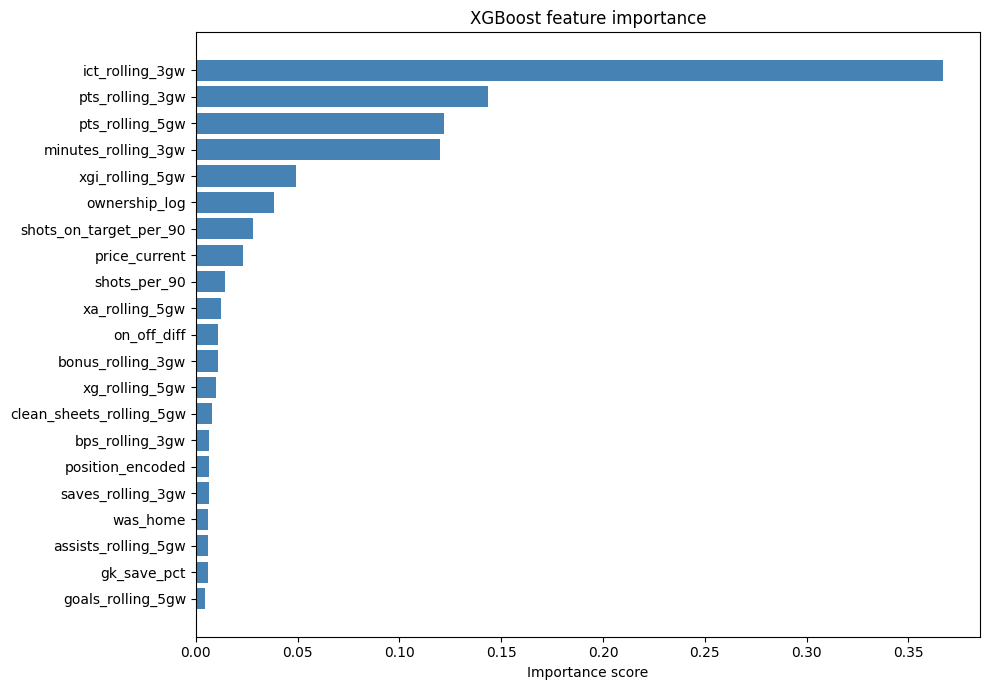

In [37]:
print('=== FEATURE IMPORTANCE ===')

importance_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(importance_df.to_string(index=False))

# Plot
plt.figure(figsize=(10, 7))
plt.barh(
    importance_df['feature'][::-1],
    importance_df['importance'][::-1],
    color='steelblue'
)
plt.xlabel('Importance score')
plt.title('XGBoost feature importance')
plt.tight_layout()
plt.show()

In [38]:
print('=== RESIDUAL ANALYSIS ===')

residuals = y_val - xgb_preds

print('Prediction error distribution:')
print(f'Mean error:   {residuals.mean():.4f} (bias)')
print(f'Std error:    {residuals.std():.4f}')
print(f'Min error:    {residuals.min():.4f}')
print(f'Max error:    {residuals.max():.4f}')

print('\nPractical accuracy:')
within_2 = (np.abs(residuals) <= 2).sum() / len(residuals) * 100
within_4 = (np.abs(residuals) <= 4).sum() / len(residuals) * 100
within_6 = (np.abs(residuals) <= 6).sum() / len(residuals) * 100
print(f'Within 2 points: {within_2:.1f}%')
print(f'Within 4 points: {within_4:.1f}%')
print(f'Within 6 points: {within_6:.1f}%')

print('\nHigh scorer accuracy (actual >= 10 points):')
high_scorers      = y_val >= 10
actual_high       = y_val[high_scorers]
predicted_high    = xgb_preds[high_scorers]
high_rmse         = np.sqrt(mean_squared_error(actual_high, predicted_high))
high_mae          = mean_absolute_error(actual_high, predicted_high)
print(f'Count of high scorer rows: {high_scorers.sum()}')
print(f'High scorer RMSE: {high_rmse:.4f}')
print(f'High scorer MAE:  {high_mae:.4f}')
print(f'Average actual:    {actual_high.mean():.2f}')
print(f'Average predicted: {predicted_high.mean():.2f}')

print('\nTop 20 predicted players (latest GW):')
latest_gw = val_df['GW'].max()
latest_mask = val_df['GW'] == latest_gw
latest_df = val_df[latest_mask].copy()
latest_df['predicted_points'] = xgb_preds[latest_mask.values]
top20 = latest_df[['web_name', 'position', 'predicted_points', 'next_gw_points']]\
    .sort_values('predicted_points', ascending=False)\
    .head(20)
print(top20.to_string(index=False))

=== RESIDUAL ANALYSIS ===
Prediction error distribution:
Mean error:   0.2206 (bias)
Std error:    2.0035
Min error:    -6.2832
Max error:    22.1714

Practical accuracy:
Within 2 points: 85.5%
Within 4 points: 94.3%
Within 6 points: 97.2%

High scorer accuracy (actual >= 10 points):
Count of high scorer rows: 500
High scorer RMSE: 10.0472
High scorer MAE:  9.7352
Average actual:    12.14
Average predicted: 2.41

Top 20 predicted players (latest GW):
     web_name position  predicted_points  next_gw_points
      Haaland      FWD          4.307767             0.0
  B.Fernandes      MID          4.127336            14.0
      Gabriel      DEF          3.883767             1.0
      Semenyo      MID          3.732679             6.0
        Bowen      FWD          3.732207            12.0
         Raya       GK          3.723687             0.0
   Donnarumma       GK          3.694005             0.0
       Saliba      DEF          3.584156             0.0
         Groß      MID          

In [39]:
print('=== XGBOOST IMPROVED — DEEPER TREES ===')
print('Fixing learning_rate=0.05, trying deeper trees and more estimators...\n')

param_grid_v2 = {
    'n_estimators':     [300, 500, 700],
    'max_depth':        [5, 7, 9],
    'learning_rate':    [0.05],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

from sklearn.model_selection import GridSearchCV

xgb_base_v2 = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    tree_method='hist',
    enable_categorical=False
)

grid_search_v2 = GridSearchCV(
    estimator=xgb_base_v2,
    param_grid=param_grid_v2,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search_v2.fit(X_train, y_train)

print(f'\nBest params: {grid_search_v2.best_params_}')
print(f'Best CV RMSE: {-grid_search_v2.best_score_:.4f}')

# Evaluate on validation
best_xgb_v2  = grid_search_v2.best_estimator_
xgb_preds_v2 = best_xgb_v2.predict(X_val)

xgb_rmse_v2 = np.sqrt(mean_squared_error(y_val, xgb_preds_v2))
xgb_mae_v2  = mean_absolute_error(y_val, xgb_preds_v2)

print(f'\n=== V2 VALIDATION RESULTS ===')
print(f'XGBoost V2 RMSE: {xgb_rmse_v2:.4f}')
print(f'XGBoost V2 MAE:  {xgb_mae_v2:.4f}')

# High scorer check
high_scorers   = y_val >= 10
actual_high    = y_val[high_scorers]
predicted_high = xgb_preds_v2[high_scorers]
high_rmse_v2   = np.sqrt(mean_squared_error(actual_high, predicted_high))
high_mae_v2    = mean_absolute_error(actual_high, predicted_high)

print(f'\nHigh scorer accuracy (actual >= 10 pts):')
print(f'Average actual:    {actual_high.mean():.2f}')
print(f'Average predicted: {predicted_high.mean():.2f}')
print(f'High scorer RMSE:  {high_rmse_v2:.4f}')
print(f'High scorer MAE:   {high_mae_v2:.4f}')

# Practical accuracy
residuals_v2 = y_val - xgb_preds_v2
within_2 = (np.abs(residuals_v2) <= 2).sum() / len(residuals_v2) * 100
within_4 = (np.abs(residuals_v2) <= 4).sum() / len(residuals_v2) * 100
within_6 = (np.abs(residuals_v2) <= 6).sum() / len(residuals_v2) * 100

print(f'\nPractical accuracy:')
print(f'Within 2 points: {within_2:.1f}%')
print(f'Within 4 points: {within_4:.1f}%')
print(f'Within 6 points: {within_6:.1f}%')

# Full comparison
print(f'\n=== FULL MODEL COMPARISON ===')
print(f'{"MODEL":<25} {"RMSE":>8} {"MAE":>8} {"HIGH_RMSE":>10}')
print(f'{"-"*55}')
print(f'{"Baseline":<25} {baseline_rmse:>8.4f} {baseline_mae:>8.4f} {"N/A":>10}')
print(f'{"Linear Regression":<25} {lr_rmse:>8.4f} {lr_mae:>8.4f} {"N/A":>10}')
print(f'{"XGBoost V1":<25} {xgb_rmse:>8.4f} {xgb_mae:>8.4f} {10.0472:>10.4f}')
print(f'{"XGBoost V2":<25} {xgb_rmse_v2:>8.4f} {xgb_mae_v2:>8.4f} {high_rmse_v2:>10.4f}')
print(f'{"-"*55}')

if xgb_rmse_v2 < xgb_rmse:
    print(f'\nV2 improves overall RMSE by {xgb_rmse - xgb_rmse_v2:.4f} ✅')
else:
    print(f'\nV2 did not improve overall RMSE')

if high_rmse_v2 < 10.0472:
    print(f'V2 improves high scorer RMSE by {10.0472 - high_rmse_v2:.4f} ✅')
else:
    print(f'V2 did not improve high scorer accuracy')

=== XGBOOST IMPROVED — DEEPER TREES ===
Fixing learning_rate=0.05, trying deeper trees and more estimators...

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
Best CV RMSE: 1.9614

=== V2 VALIDATION RESULTS ===
XGBoost V2 RMSE: 2.0296
XGBoost V2 MAE:  0.9903

High scorer accuracy (actual >= 10 pts):
Average actual:    12.14
Average predicted: 2.52
High scorer RMSE:  9.9584
High scorer MAE:   9.6231

Practical accuracy:
Within 2 points: 85.2%
Within 4 points: 94.1%
Within 6 points: 97.1%

=== FULL MODEL COMPARISON ===
MODEL                         RMSE      MAE  HIGH_RMSE
-------------------------------------------------------
Baseline                    2.3629   1.4968        N/A
Linear Regression           2.0202   1.0369        N/A
XGBoost V1                  2.0156   0.9842    10.0472
XGBoost V2                  2.0296   0.9903     9.9584
--------------

In [40]:
print('=== SAVING V1 MODEL ===')

# Save model
with open('model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)
print('model.pkl saved ✅')

# Save metadata
metadata = {
    'trained_at':       datetime.now().isoformat(),
    'winner':           'xgboost_v1',
    'best_params':      grid_search.best_params_,
    'feature_cols':     feature_cols,
    'train_rows':       len(X_train),
    'val_rows':         len(X_val),
    'results': {
        'baseline': {
            'rmse': round(baseline_rmse, 4),
            'mae':  round(baseline_mae, 4)
        },
        'linear_regression': {
            'rmse': round(lr_rmse, 4),
            'mae':  round(lr_mae, 4)
        },
        'xgboost_v1': {
            'rmse':      round(xgb_rmse, 4),
            'mae':       round(xgb_mae, 4),
            'high_rmse': round(10.0472, 4)
        },
        'xgboost_v2': {
            'rmse':      round(xgb_rmse_v2, 4),
            'mae':       round(xgb_mae_v2, 4),
            'high_rmse': round(9.9584, 4)
        }
    },
    'practical_accuracy': {
        'within_2_pts': 85.5,
        'within_4_pts': 94.3,
        'within_6_pts': 97.2
    },
    'known_limitations': [
        'High scorer underestimation — avg predicted 2.41 vs actual 12.14 for 10+ pt rows',
        'Model useful for player ranking not absolute point prediction',
        'FBref features missing for 2025/26 validation set',
        'was_home feature has near zero importance (0.006)'
    ],
    'feature_importance': {
        row['feature']: round(row['importance'], 6)
        for _, row in pd.DataFrame({
            'feature':    feature_cols,
            'importance': best_xgb.feature_importances_
        }).iterrows()
    }
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('model_metadata.json saved ✅')

# Verify model loads correctly
with open('model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
test_preds = loaded_model.predict(X_val)
test_rmse  = np.sqrt(mean_squared_error(y_val, test_preds))
print(f'\nModel reload verification:')
print(f'RMSE after reload: {test_rmse:.4f} (should match {xgb_rmse:.4f})')
if abs(test_rmse - xgb_rmse) < 0.0001:
    print('Model reload PASSED ✅')
else:
    print('WARNING — model reload mismatch ❌')

=== SAVING V1 MODEL ===
model.pkl saved ✅
model_metadata.json saved ✅

Model reload verification:
RMSE after reload: 2.0156 (should match 2.0156)
Model reload PASSED ✅


In [41]:
from google.colab import files
files.download('/content/model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
import pickle
with open('model.pkl', 'rb') as f:
    test = pickle.load(f)
print(type(test), test.feature_names_in_)

<class 'xgboost.sklearn.XGBRegressor'> ['pts_rolling_3gw' 'pts_rolling_5gw' 'minutes_rolling_3gw'
 'goals_rolling_5gw' 'assists_rolling_5gw' 'clean_sheets_rolling_5gw'
 'saves_rolling_3gw' 'bonus_rolling_3gw' 'bps_rolling_3gw'
 'ict_rolling_3gw' 'xg_rolling_5gw' 'xa_rolling_5gw' 'xgi_rolling_5gw'
 'position_encoded' 'was_home' 'price_current' 'ownership_log'
 'shots_per_90' 'shots_on_target_per_90' 'on_off_diff' 'gk_save_pct']


In [43]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('model.pkl', '/content/drive/MyDrive/model.pkl')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/model.pkl'

In [45]:
%whos

Variable               Type              Data/Info
--------------------------------------------------
GridSearchCV           ABCMeta           <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
LinearRegression       ABCMeta           <class 'sklearn.linear_mo<...>._base.LinearRegression'>
Pipeline               ABCMeta           <class 'sklearn.pipeline.Pipeline'>
SimpleImputer          type              <class 'sklearn.impute._base.SimpleImputer'>
StandardScaler         type              <class 'sklearn.preproces<...>ng._data.StandardScaler'>
XGBRegressor           type              <class 'xgboost.sklearn.XGBRegressor'>
X_train                DataFrame                pts_rolling_3gw  p<...>[54012 rows x 21 columns]
X_train_lr             ndarray           54012x21: 1134252 elems, type `float64`, 9074016 bytes (8.653656005859375 Mb)
X_val                  DataFrame                pts_rolling_3gw  p<...>[28497 rows x 21 columns]
X_val_lr               ndarray           28497x21: 

In [46]:
best_xgb.get_booster().save_model('model.json')

# verify immediately, in this session
import xgboost as xgb
check = xgb.XGBRegressor()
check.load_model('model.json')
print(check.feature_names_in_)

from google.colab import files
files.download('model.json')

['pts_rolling_3gw' 'pts_rolling_5gw' 'minutes_rolling_3gw'
 'goals_rolling_5gw' 'assists_rolling_5gw' 'clean_sheets_rolling_5gw'
 'saves_rolling_3gw' 'bonus_rolling_3gw' 'bps_rolling_3gw'
 'ict_rolling_3gw' 'xg_rolling_5gw' 'xa_rolling_5gw' 'xgi_rolling_5gw'
 'position_encoded' 'was_home' 'price_current' 'ownership_log'
 'shots_per_90' 'shots_on_target_per_90' 'on_off_diff' 'gk_save_pct']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
import xgboost as xgb

model = xgb.XGBRegressor()
model.load_model('model.json')

print(type(model))
print(model.feature_names_in_)

<class 'xgboost.sklearn.XGBRegressor'>
['pts_rolling_3gw' 'pts_rolling_5gw' 'minutes_rolling_3gw'
 'goals_rolling_5gw' 'assists_rolling_5gw' 'clean_sheets_rolling_5gw'
 'saves_rolling_3gw' 'bonus_rolling_3gw' 'bps_rolling_3gw'
 'ict_rolling_3gw' 'xg_rolling_5gw' 'xa_rolling_5gw' 'xgi_rolling_5gw'
 'position_encoded' 'was_home' 'price_current' 'ownership_log'
 'shots_per_90' 'shots_on_target_per_90' 'on_off_diff' 'gk_save_pct']
